# Country Prediction from Google Street View Images

This notebook shows how the model works using images from the Google Street View Static API. You'll need to add your `GOOGLE_API_KEY` to the .env file before running it.

In [15]:
location = input("Enter a location for Street View: ")

Enter a location for Street View:  Greenland


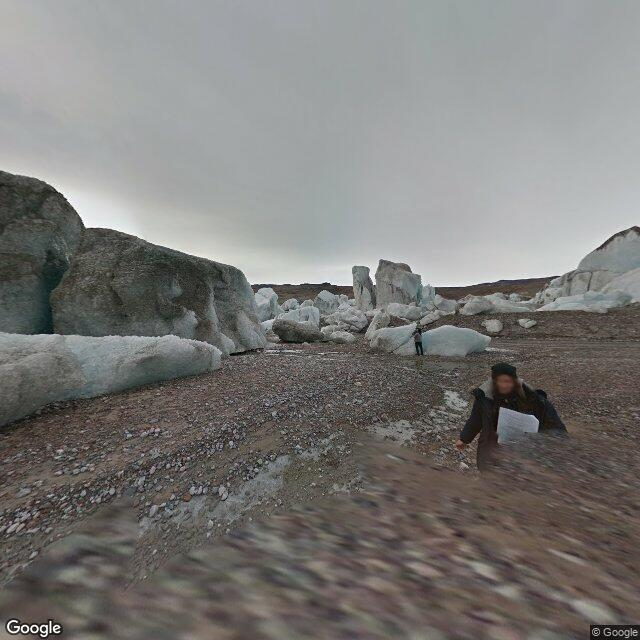

In [16]:
import os
import requests
from PIL import Image
from io import BytesIO
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("GOOGLE_API_KEY")

assert API_KEY is not None, "GOOGLE_API_KEY not found"

BASE_URL = "https://maps.googleapis.com/maps/api/streetview"

params = {
    "size": "640x640",
    "location": location,
    "heading": 90,
    "fov": 180,
    "pitch": 0,
    "key": API_KEY
}

response = requests.get(BASE_URL, params=params)
image = Image.open(BytesIO(response.content))
image

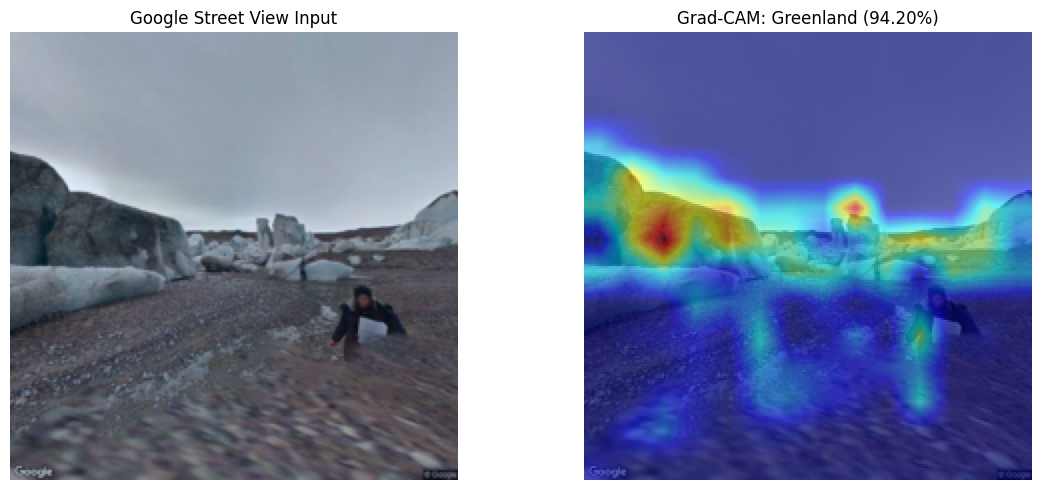

Top predicted countries:
Greenland                 : 94.20%
Norway                    : 2.26%
Netherlands               : 2.04%
Iceland                   : 0.34%
Australia                 : 0.27%


In [17]:
import torch
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from src.model import ViTModel
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load('model/ViTModel/best.pth')
model = ViTModel(num_classes=len(checkpoint["label_map"]), pretrained=False)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image_tensor = transform(image).unsqueeze(0).to(DEVICE)

top_k = 5
model.eval()

with torch.no_grad():
    outputs = model(image_tensor)
    probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]

topk_indices = probabilities.argsort()[-top_k:][::-1]
topk_probs = probabilities[topk_indices]

# label map (same logic as your dataset code)
idx_to_name = {v: k for k, v in checkpoint["label_map"].items()}
topk_countries = [idx_to_name[i] for i in topk_indices]

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

target_layers = [model.vit.blocks[-1].norm1]

cam = GradCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

targets = [ClassifierOutputTarget(topk_indices[0])]
grayscale_cam = cam(input_tensor=image_tensor, targets=targets)[0]


input_image = image_tensor[0].permute(1, 2, 0).cpu().numpy()
input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())

cam_image = show_cam_on_image(input_image, grayscale_cam, use_rgb=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(input_image)
axs[0].axis("off")
axs[0].set_title("Google Street View Input")

axs[1].imshow(cam_image)
axs[1].axis("off")
axs[1].set_title(
    f"Grad-CAM: {topk_countries[0]} ({topk_probs[0]*100:.2f}%)"
)

plt.tight_layout()
plt.show()

print("Top predicted countries:")
for country, prob in zip(topk_countries, topk_probs):
    print(f"{country:25s} : {prob*100:.2f}%")